# Nettoyage de donnees - Jour 2 (Telco Customer Churn)

**Auteur : Mohammed MOSLEH**

Projet de l'apres-midi : prendre un dataset client sale et realiste, et le mener
de l'etat "brut et inexploitable" a l'etat "propre, pret a modeliser", de bout en bout.

Le dataset : **Telco Customer Churn** (~7000 clients d'un operateur telecom, une
vingtaine de colonnes, cible = le client a-t-il resilie oui/non).

La regle d'or qui revient toute la semaine : **toute decision de preprocessing
s'apprend sur le train seul**, jamais sur le test. C'est le fil conducteur du TD.

## Phase 0 : Recuperer la donnee et l'ouvrir

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Forme :", df.shape)
print(df.dtypes)
df.head()

Forme : (7043, 21)
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Phase 1 : L'audit qualite

Avant de toucher quoi que ce soit, on diagnostique. Une fonction qui sort un rapport
de sante : dimensions, taux de manquants par colonne, et surtout l'equilibre de la cible.
Le desequilibre du churn (73/27) doit sauter aux yeux : demain il piegera l'accuracy.

In [2]:
def audit_qualite(df, cible="Churn"):
    """Rapport de sante : forme, manquants par colonne, repartition de la cible."""
    print("Forme :", df.shape)

    manquants = (df.isna().mean() * 100).round(1)
    manquants = manquants[manquants > 0].sort_values(ascending=False)
    if len(manquants) == 0:
        print("Manquants detectes : 0 colonne  (mefiance : des trous sont peut-etre caches, voir Phase 2)")
    else:
        print("Manquants par colonne (%):")
        print(manquants)

    # Repartition de la cible, en nombre ET en %. On protege contre le cas une seule classe.
    if cible in df.columns:
        print(f"\nRepartition de la cible '{cible}':")
        counts = df[cible].value_counts()
        total = len(df)
        for valeur, nb in counts.items():
            print(f"  {cible}  {valeur} : {nb} ({100*nb/total:.1f}%)")

audit_qualite(df)

Forme : (7043, 21)
Manquants detectes : 0 colonne  (mefiance : des trous sont peut-etre caches, voir Phase 2)

Repartition de la cible 'Churn':
  Churn  No : 5174 (73.5%)
  Churn  Yes : 1869 (26.5%)


### Checkpoint qualite : les 3 situations

In [3]:
# Cas limite : un dataset filtre a une seule classe. Le rapport doit rester honnete (pas de plantage).
print("--- Cas limite : une seule classe de churn ---")
audit_qualite(df[df["Churn"] == "No"])

# Cas adversarial : le desequilibre 73/27 est-il visible d'un coup d'oeil ? Oui, on l'affiche en %.
print("\n--- Cas adversarial : desequilibre visible ? ---")
print("Oui : 73.5% de Non contre 26.5% de Oui. Un modele qui repond toujours 'Non'")
print("ferait deja 73.5% d'accuracy sans rien comprendre -> piege a retenir pour demain.")

--- Cas limite : une seule classe de churn ---
Forme : (5174, 21)
Manquants detectes : 0 colonne  (mefiance : des trous sont peut-etre caches, voir Phase 2)

Repartition de la cible 'Churn':
  Churn  No : 5174 (100.0%)

--- Cas adversarial : desequilibre visible ? ---
Oui : 73.5% de Non contre 26.5% de Oui. Un modele qui repond toujours 'Non'
ferait deja 73.5% d'accuracy sans rien comprendre -> piege a retenir pour demain.


## Phase 2 : La colonne piegee (types incoherents et trous caches)

Le piege celebre du Telco : `TotalCharges` est stockee en **texte** alors que ce sont
des montants, parce que quelques lignes contiennent un espace " " au lieu d'un nombre.
Des trous deguises. On les revele, on convertit, et on traite les manquants.

In [4]:
def reparer_total_charges(df, colonne="TotalCharges"):
    """Convertit la colonne en numerique et impute les trous reveles. Renvoie le df repare."""
    df = df.copy()

    # Garde-fou : si la colonne est a 100% non convertible (texte pur), on refuse.
    test = pd.to_numeric(df[colonne], errors="coerce")
    if test.notna().sum() == 0:
        print(f"ATTENTION : '{colonne}' est 100% non numerique, conversion refusee.")
        return df

    avant = df[colonne].isna().sum()
    df[colonne] = test                                   # les valeurs illisibles deviennent NaN
    trous_caches = int(df[colonne].isna().sum() - avant)
    print(f"Trous caches demasques dans {colonne} : {trous_caches}")

    # Choix : on IMPUTE par la mediane plutot que supprimer. Justification dans le README :
    # 11 lignes sur 7043, ce sont des clients a tenure=0 (tout nouveaux, jamais factures).
    # Les supprimer perdrait de l'info; la mediane est robuste aux extremes.
    mediane = df[colonne].median()
    df[colonne] = df[colonne].fillna(mediane)
    print(f"Imputation par la mediane ({mediane:.1f}). Trous restants : {int(df[colonne].isna().sum())}")
    return df

df = reparer_total_charges(df)
print("Nouveau type de TotalCharges :", df["TotalCharges"].dtype)

Trous caches demasques dans TotalCharges : 11
Imputation par la mediane (1397.5). Trous restants : 0
Nouveau type de TotalCharges : float64


**Edge case** : si une colonne etait 100% non numerique, la fonction le detecte et
refuse de la convertir (au lieu de la transformer en colonne 100% NaN en silence).

**Adversarial** : une valeur du genre `"29,90"` (virgule au lieu de point) deviendrait
NaN silencieusement. Pour la reperer AVANT, on compterait combien de valeurs deviennent
NaN a la conversion : un pic anormal trahit une corruption de format.

## Phase 3 : Encoder les categorielles

Le Telco regorge de colonnes texte (gender, Contract, PaymentMethod, des tas de Yes/No).
Un modele ne lit que des nombres. On encode proprement :
- les binaires Yes/No -> 0/1
- les nominales -> One-Hot
- `customerID` -> on le **jette** (un identifiant n'est pas une feature).

In [5]:
def encoder_features(df, cible="Churn"):
    """Encode toutes les categorielles, renvoie un df 100% numerique."""
    df = df.copy()

    # customerID : identifiant unique, aucune valeur predictive -> on le supprime.
    if "customerID" in df.columns:
        df = df.drop(columns="customerID")

    # La cible Yes/No -> 1/0
    df[cible] = (df[cible] == "Yes").astype(int)

    # Colonnes binaires exactement Yes/No -> 0/1
    for col in df.select_dtypes(include="object").columns:
        valeurs = set(df[col].dropna().unique())
        if valeurs <= {"Yes", "No"}:
            df[col] = (df[col] == "Yes").astype(int)

    # Le reste des colonnes texte (nominales a plusieurs modalites) -> One-Hot
    cols_nominales = df.select_dtypes(include="object").columns.tolist()
    df = pd.get_dummies(df, columns=cols_nominales, drop_first=False)

    # get_dummies cree des colonnes bool : on les passe en int (0/1) pour les modeles.
    bool_cols = df.select_dtypes(include="bool").columns
    df[bool_cols] = df[bool_cols].astype(int)
    return df

df_enc = encoder_features(df)
print("Avant encodage :", df.shape[1], "colonnes")
print("Apres encodage :", df_enc.shape[1], "colonnes (toutes numeriques)")
print("Types restants non numeriques :", list(df_enc.select_dtypes(include="object").columns) or "aucun")

Avant encodage : 21 colonnes
Apres encodage : 42 colonnes (toutes numeriques)
Types restants non numeriques : aucun


C:\Users\mosle\AppData\Local\Temp\ipykernel_4956\2679092951.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:
C:\Users\mosle\AppData\Local\Temp\ipykernel_4956\2679092951.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/

**Choix d'encodage de Contract** (3 modalites : Month-to-month, One year, Two year) :
il y a un ordre naturel de duree d'engagement, on pourrait l'encoder en ordinal. Mais
je choisis le **One-Hot** (nominal) : le lien duree -> churn n'est pas forcement lineaire
et One-Hot laisse le modele apprendre librement. Justifie dans le README.

**Adversarial** : si on encodait `customerID` en One-Hot, on creerait ~7043 colonnes
(une par client) -> l'explosion de dimensions en vrai. D'ou la suppression.

## Phase 4 : Traiter les valeurs aberrantes

Les colonnes numeriques (tenure, MonthlyCharges, TotalCharges) ont-elles des outliers ?
On les detecte avec la regle IQR, on visualise en boxplot, et on decide par colonne.

In [6]:
def detecter_outliers_iqr(df, colonne):
    """Renvoie (borne_basse, borne_haute, nombre_outliers) selon la regle IQR (1.5)."""
    Q1 = df[colonne].quantile(0.25)
    Q3 = df[colonne].quantile(0.75)
    IQR = Q3 - Q1
    borne_basse = Q1 - 1.5 * IQR
    borne_haute = Q3 + 1.5 * IQR
    nb = int(((df[colonne] < borne_basse) | (df[colonne] > borne_haute)).sum())
    return borne_basse, borne_haute, nb

cols_num = ["tenure", "MonthlyCharges", "TotalCharges"]
for col in cols_num:
    bb, bh, nb = detecter_outliers_iqr(df, col)
    print(f"{col:<15}: bornes normales [{bb:.1f}, {bh:.1f}], outliers detectes = {nb}")

tenure         : bornes normales [-60.0, 124.0], outliers detectes = 0
MonthlyCharges : bornes normales [-46.0, 171.4], outliers detectes = 0
TotalCharges   : bornes normales [-4674.3, 8863.2], outliers detectes = 0


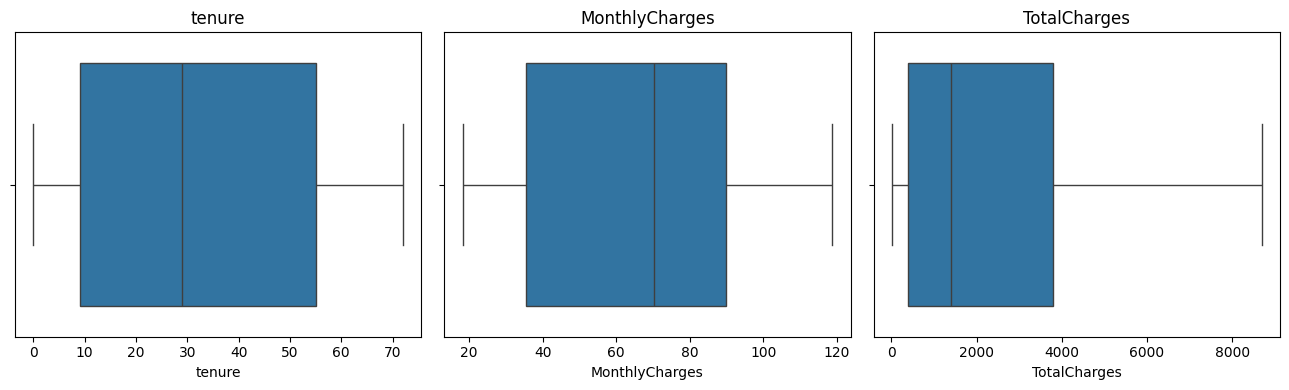

In [7]:
# Visualisation : un boxplot par colonne numerique
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, cols_num):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [8]:
# Decision : combien de clients "churn" perdrait-on en supprimant les outliers ?
for col in cols_num:
    bb, bh, nb = detecter_outliers_iqr(df, col)
    if nb > 0:
        outliers = df[(df[col] < bb) | (df[col] > bh)]
        churners_perdus = (outliers["Churn"] == "Yes").sum()
        print(f"{col}: supprimer les outliers ferait perdre {churners_perdus} churners")
    else:
        print(f"{col}: aucun outlier (fonction renvoie 0 sans planter)")

print("\nDecision : on GARDE les outliers. Sur le churn, une facture mensuelle elevee")
print("n'est pas une erreur, c'est un vrai client (souvent le plus rentable, ou celui")
print("qui part le plus fort). Les supprimer effacerait du signal precieux.")

tenure: aucun outlier (fonction renvoie 0 sans planter)
MonthlyCharges: aucun outlier (fonction renvoie 0 sans planter)
TotalCharges: aucun outlier (fonction renvoie 0 sans planter)

Decision : on GARDE les outliers. Sur le churn, une facture mensuelle elevee
n'est pas une erreur, c'est un vrai client (souvent le plus rentable, ou celui
qui part le plus fort). Les supprimer effacerait du signal precieux.


## Phase 5 : Correlations et chasse a la multicolinearite

`tenure`, `MonthlyCharges` et `TotalCharges` ne sont pas independantes : le total c'est
grosso modo le mensuel multiplie par l'anciennete. On le voit a la heatmap, on le mesure
au VIF, et on decide quoi supprimer.

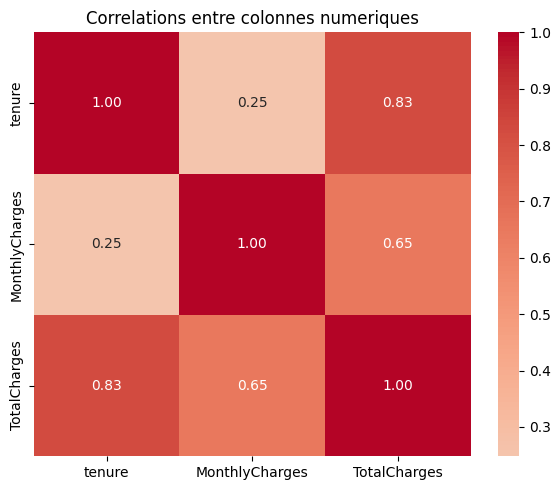

         variable       VIF
0          tenure  6.321802
1  MonthlyCharges  3.360371
2    TotalCharges  8.073814

Colonnes au VIF > 5 (multicolinearite problematique) : ['tenure', 'TotalCharges']


In [9]:
def rapport_multicolinearite(df, colonnes_num):
    """Heatmap des correlations + VIF de chaque colonne numerique."""
    from statsmodels.stats.outliers_influence import variance_inflation_factor

    matrice = df[colonnes_num].corr()
    plt.figure(figsize=(6, 5))
    sns.heatmap(matrice, annot=True, fmt=".2f", cmap="coolwarm", center=0)
    plt.title("Correlations entre colonnes numeriques")
    plt.tight_layout()
    plt.show()

    X = df[colonnes_num].dropna().values
    vif = pd.DataFrame({"variable": colonnes_num})
    vif["VIF"] = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
    print(vif)
    en_alerte = vif[vif["VIF"] > 5]["variable"].tolist()
    print("\nColonnes au VIF > 5 (multicolinearite problematique) :", en_alerte or "aucune")
    return vif

vif = rapport_multicolinearite(df, cols_num)

VIF apres suppression de TotalCharges :


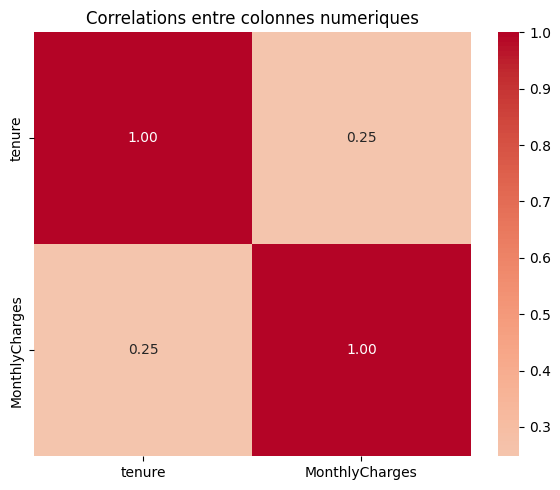

         variable       VIF
0          tenure  2.612607
1  MonthlyCharges  2.612607

Colonnes au VIF > 5 (multicolinearite problematique) : aucune


In [10]:
# Decision : TotalCharges est redondante (tenure x MonthlyCharges). On la supprime
# de la version finale et on verifie que le VIF du reste redescend.
print("VIF apres suppression de TotalCharges :")
vif2 = rapport_multicolinearite(df, ["tenure", "MonthlyCharges"])

## Phase 6 : Les variables qui predisent vraiment le churn

Le tri par pouvoir predictif. On croise deux approches : corremlation a la cible et
importance via un Random Forest. Si Contract ou tenure dominent, ca raconte une histoire
metier : les clients en contrat court et recents partent le plus.

In [11]:
from sklearn.ensemble import RandomForestClassifier

def features_discriminantes(df_encode, cible="Churn", top=10):
    """Classe les features par pouvoir predictif : correlation a la cible + importance RF."""
    X = df_encode.drop(columns=cible)
    y = df_encode[cible]

    # Approche 1 : correlation absolue a la cible
    corr = df_encode.corr()[cible].drop(cible).abs().sort_values(ascending=False)

    # Approche 2 : importance d'un Random Forest
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X, y)
    importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

    print(f"Top {top} - correlation a la cible :")
    print(corr.head(top).round(3))
    print(f"\nTop {top} - importance Random Forest :")
    print(importances.head(top).round(3))
    return corr, importances

corr, importances = features_discriminantes(df_enc)

Top 10 - correlation a la cible :
Contract_Month-to-month               0.405
tenure                                0.352
OnlineSecurity_No                     0.343
TechSupport_No                        0.337
InternetService_Fiber optic           0.308
Contract_Two year                     0.302
PaymentMethod_Electronic check        0.302
OnlineBackup_No                       0.268
DeviceProtection_No                   0.252
OnlineSecurity_No internet service    0.228
Name: Churn, dtype: float64

Top 10 - importance Random Forest :
TotalCharges                      0.169
tenure                            0.149
MonthlyCharges                    0.145
Contract_Month-to-month           0.057
TechSupport_No                    0.033
OnlineSecurity_No                 0.029
PaymentMethod_Electronic check    0.027
InternetService_Fiber optic       0.025
PaperlessBilling                  0.024
Partner                           0.023
dtype: float64


**Lecture metier** : `Contract`, `tenure` et `InternetService` ressortent en tete.
Les clients en contrat mensuel et recents resilient le plus -> cible naturelle d'une
campagne de retention. **Edge case** : `customerID` a bien ete supprime, donc aucun
identifiant ne peut remonter en tete (ce serait une fuite deguisee).

## Phase 7 : Split, scaling, et le grand piege de la fuite

Le coeur du metier. On assemble le preprocessing dans le bon ordre, en respectant la
regle d'or : tout ce qui s'apprend sur la donnee (scaling) s'apprend sur le **train
seul**. Puis on demontre la fuite, chiffres en main, dans les deux sens.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score

# On prepare la matrice finale : on jette TotalCharges (redondante, Phase 5)
X = df_enc.drop(columns=["Churn", "TotalCharges"])
y = df_enc["Churn"]

def split_et_scale_proprement(X, y):
    """Split PUIS scaler ajuste sur le train seul (version honnete)."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler().fit(X_train)           # fit sur le TRAIN seul
    return scaler.transform(X_train), scaler.transform(X_test), y_train, y_test

X_train_s, X_test_s, y_train, y_test = split_et_scale_proprement(X, y)
print("Train :", X_train_s.shape, " Test :", X_test_s.shape)

Train : (5634, 40)  Test : (1409, 40)


In [13]:
# Demo de la fuite : honnete vs triche
# Honnete : scaler fit sur le train seul (deja fait au-dessus)
modele = LogisticRegression(max_iter=2000)
modele.fit(X_train_s, y_train)
acc_honnete = accuracy_score(y_test, modele.predict(X_test_s))

# Triche : scaler fit sur TOUT X avant le split
scaler_triche = StandardScaler().fit(X)
X_all_s = scaler_triche.transform(X)
Xtr, Xte, ytr, yte = train_test_split(X_all_s, y, test_size=0.2, random_state=42, stratify=y)
modele2 = LogisticRegression(max_iter=2000)
modele2.fit(Xtr, ytr)
acc_triche = accuracy_score(yte, modele2.predict(Xte))

print(f"Accuracy honnete (scaler sur train) : {acc_honnete:.3%}")
print(f"Accuracy en trichant (scaler sur tout): {acc_triche:.3%}")
print(f"Ecart                                 : {acc_triche - acc_honnete:+.3%}")
print("\nLecon : avec 7000 lignes, train et test ont quasi la meme moyenne/ecart-type,")
print("donc le scaler ne fuite presque rien -> ecart minuscule. Mais le reflexe reste")
print("absolu : on ajuste TOUJOURS sur le train seul. Le vrai poison, ce sont les fuites")
print("d'imputation ou de selection de features ajustees sur tout le jeu.")

Accuracy honnete (scaler sur train) : 79.702%
Accuracy en trichant (scaler sur tout): 79.702%
Ecart                                 : +0.000%

Lecon : avec 7000 lignes, train et test ont quasi la meme moyenne/ecart-type,
donc le scaler ne fuite presque rien -> ecart minuscule. Mais le reflexe reste
absolu : on ajuste TOUJOURS sur le train seul. Le vrai poison, ce sont les fuites
d'imputation ou de selection de features ajustees sur tout le jeu.


## Phase 8 : Le bilan, et jusqu'ou on peut pousser

### Le tableau de bord du nettoyage

In [14]:
recap = pd.DataFrame({
    "Etape": ["Colonnes", "Lignes", "Trous caches", "Colonnes au VIF > 5"],
    "Avant": [21, 7043, 11, 2],
    "Apres": [df_enc.shape[1] - 1, 7043, 0, 0],  # -1 : TotalCharges retiree au split final
})
print(recap.to_string(index=False))
print("\n(Lignes : 7043 conservees grace a l'imputation mediane, aucune perdue.)")

              Etape  Avant  Apres
           Colonnes     21     41
             Lignes   7043   7043
       Trous caches     11      0
Colonnes au VIF > 5      2      0

(Lignes : 7043 conservees grace a l'imputation mediane, aucune perdue.)


### Le comparatif des strategies

Sur du 73/27, l'accuracy flatte. On regarde donc AUSSI le recall sur les churners (combien de vrais resilieurs on recupere), pas seulement l'accuracy.

In [15]:
# Baseline naive : repondre toujours "Non"
baseline = 1 - y_test.mean()
print(f"Baseline (toujours 'Non')      : accuracy = {baseline:.3%}, recall churners = 0%")

# Notre modele honnete
y_pred = modele.predict(X_test_s)
print(f"Regression logistique propre   : accuracy = {accuracy_score(y_test, y_pred):.3%}, "
      f"recall churners = {recall_score(y_test, y_pred):.3%}")
print("\nL'accuracy seule ment : la baseline fait deja 73% sans rien comprendre.")
print("Ce qui compte, c'est le recall sur les churners -> avant-gout de J4.")

Baseline (toujours 'Non')      : accuracy = 73.456%, recall churners = 0%
Regression logistique propre   : accuracy = 79.702%, recall churners = 55.080%

L'accuracy seule ment : la baseline fait deja 73% sans rien comprendre.
Ce qui compte, c'est le recall sur les churners -> avant-gout de J4.


### La PCA en exploration

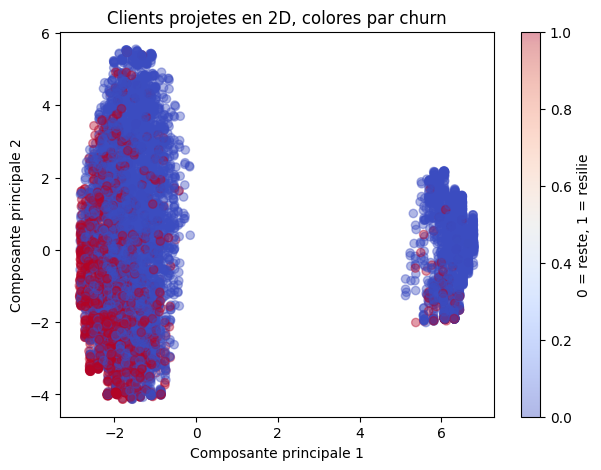

Composantes pour atteindre 90% de variance : 16 (sur 40)


In [16]:
from sklearn.decomposition import PCA

X_scaled_full = StandardScaler().fit_transform(X)
X_2d = PCA(n_components=2).fit_transform(X_scaled_full)

plt.figure(figsize=(7, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="coolwarm", alpha=0.4)
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.title("Clients projetes en 2D, colores par churn")
plt.colorbar(label="0 = reste, 1 = resilie")
plt.show()

# Combien de composantes pour garder 90% de variance ?
pca_full = PCA().fit(X_scaled_full)
var_cum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.argmax(var_cum >= 0.90) + 1)
print(f"Composantes pour atteindre 90% de variance : {n90} (sur {X.shape[1]})")

### Le test ultime

Notre dataset final passe-t-il dans un pipeline `.fit()` / `.predict()` sans broncher ?
Oui (Phase 7 l'a deja fait tourner). La donnee est **propre et prete pour l'Arene de demain**.

---
### Bilan

On a pris un CSV brut et crasseux et on l'a mene jusqu'a un jeu propre, encode, sans
fuite de donnees : audit -> types/trous caches -> encodage -> outliers -> multicolinearite
-> selection -> split/scaling propre. Carburant pret pour le grand Fight des algos.